# Natural Gas Storage Contract — Pricing Model
    Task 2: Price a commodity storage contract given injection/withdrawal
    dates, volumes, rates, storage capacity, and cost parameters.


# Cash flows considered
      + Revenue   : gas sold at withdrawal price × volume withdrawn
      - Cost      : gas bought at injection price × volume injected
      - Storage   : monthly fee × months gas sits in storage
      - Injection : per-MMBtu fee on every unit injected
      - Withdrawal: per-MMBtu fee on every unit withdrawn
# Steps
      1. Rebuild the price estimator from Task 1
      2. Define the contract_value() pricing function
      3. Validate inputs (capacity, rate, date ordering)
      4. Run test cases and produce a summary report

### Import libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from scipy import stats
from datetime import datetime

# Price estimate function building

In [2]:
gass=pd.read_csv("Nat_Gas.csv")
gass.columns=gass.columns.str.strip()
gass["Dates"]=pd.to_datetime(gass["Dates"],format="%m/%d/%y")
gass["Prices"]=gass["Prices"].astype(float)
gass=gass[["Dates","Prices"]].sort_values("Dates").reset_index(drop=True)

In [3]:
# Convert dates to a numeric "years since start" for regression
t0=gass["Dates"].min()
gass["t"]=(gass['Dates']-t0).dt.days/365.25

In [4]:
slope,intercept,r_value,p_value,std_err=stats.linregress(gass['t'],gass['Prices'])
gass['trend']= intercept+ slope*gass["t"]
gass['residual']= gass["Prices"] -gass["trend"]

In [8]:
# Monthly seasonal index = mean residual per calendar month
gass["Month"] = gass["Dates"].dt.month
seasonal_idx= gass.groupby('Month')["residual"].mean()
print("Linear trend:")
print(f"  Intercept : ${intercept:.4f}  (price at t=0, Oct 2020)")
print(f"  Slope     : ${slope:.4f} per year")
print(f"  R²        : {r_value**2:.4f}")
print("\nMonthly seasonal index (± vs trend):")

Linear trend:
  Intercept : $10.2910  (price at t=0, Oct 2020)
  Slope     : $0.4684 per year
  R²        : 0.5196

Monthly seasonal index (± vs trend):


In [9]:
def estimate_price(date_str: str) -> float:
    """Return estimated nat-gas price (USD/MMBtu) for any date."""
    date  = pd.to_datetime(date_str)
    t     = (date - t0).days / 365.25
    month = date.month
    return round(intercept + slope * t + seasonal_idx[month], 4)

In [10]:
print(f"Price model ready.  Trend slope: ${slope:.4f}/yr")
print(f"Sample check — Jun 2025: ${estimate_price('2025-06-30'):.2f}  |  "
      f"Dec 2024: ${estimate_price('2024-12-31'):.2f}")

Price model ready.  Trend slope: $0.4684/yr
Sample check — Jun 2025: $11.87  |  Dec 2024: $12.87


# Contract pricing function

In [17]:
def contract_value(
    injection_dates:    list,   # list of date strings, e.g. ["2024-06-30","2024-07-31"]
    withdrawal_dates:   list,   # list of date strings
    injection_prices:   list,   # USD/MMBtu; pass None to use model estimate
    withdrawal_prices:  list,   # USD/MMBtu; pass None to use model estimate
    injection_rate:     float,  # max MMBtu injected per single injection event
    withdrawal_rate:    float,  # max MMBtu withdrawn per single withdrawal event
    max_storage:        float,  # MMBtu — hard storage capacity ceiling
    storage_cost:       float,  # USD per MMBtu per month in storage
    injection_cost:     float = 0.0,   # USD per MMBtu injected (variable fee)
    withdrawal_cost:    float = 0.0,   # USD per MMBtu withdrawn (variable fee)
    verbose:            bool  = True,
) -> dict:
    """
    Price a natural gas storage contract.

    Returns
    -------
    dict with keys:
        value               – net contract value (USD)
        injection_spend     – total gas purchase cost
        withdrawal_revenue  – total gas sale revenue
        storage_fee         – total storage cost paid
        injection_fee       – total injection variable cost
        withdrawal_fee      – total withdrawal variable cost
        cashflows           – DataFrame of every event
        error               – None if valid, else error string
    """

    # ── Input validation ──────────────────────────────────
    if len(injection_dates) == 0 or len(withdrawal_dates) == 0:
        return {"error": "Must supply at least one injection and one withdrawal date.",
                "value": None}

    inj_dates  = sorted(pd.to_datetime(injection_dates))
    with_dates = sorted(pd.to_datetime(withdrawal_dates))

    if inj_dates[-1] >= with_dates[0]:
        return {"error": "All injection dates must precede all withdrawal dates.",
                "value": None}

    if injection_rate <= 0 or withdrawal_rate <= 0:
        return {"error": "Injection and withdrawal rates must be positive.", "value": None}

    if max_storage <= 0:
        return {"error": "max_storage must be positive.", "value": None}

    # ── Resolve prices (model estimate if not supplied) ───
    def resolve_prices(dates, prices_in, label):
        if prices_in is None:
            return [estimate_price(str(d.date())) for d in dates]
        if len(prices_in) != len(dates):
            raise ValueError(f"Length of {label}_prices must match {label}_dates.")
        return list(prices_in)

    inj_prices  = resolve_prices(inj_dates,  injection_prices,  "injection")
    with_prices = resolve_prices(with_dates, withdrawal_prices, "withdrawal")

    # ── Volume per event (capped by rate and remaining capacity) ─
    storage_level = 0.0
    events = []

    # Injection events
    for d, p in zip(inj_dates, inj_prices):
        room           = max_storage - storage_level
        vol            = min(injection_rate, room)
        storage_level += vol
        events.append({
            "date": d, "type": "inject",
            "volume_MMBtu": vol, "price_USD_MMBtu": p,
            "storage_after": storage_level
        })

    # Withdrawal events
    for d, p in zip(with_dates, with_prices):
        vol            = min(withdrawal_rate, storage_level)
        storage_level -= vol
        events.append({
            "date": d, "type": "withdraw",
            "volume_MMBtu": vol, "price_USD_MMBtu": p,
            "storage_after": storage_level
        })

    events_df = pd.DataFrame(events).sort_values("date").reset_index(drop=True)

    # ── Storage cost: fee per MMBtu-month ─────────────────
    # For each pair of consecutive events, charge for the
    # volume sitting in storage × the fractional months elapsed.
    total_storage_fee = 0.0
    events_df["storage_fee"] = 0.0
    for i in range(1, len(events_df)):
        vol_held    = events_df.loc[i - 1, "storage_after"]
        days        = (events_df.loc[i, "date"] - events_df.loc[i - 1, "date"]).days
        months      = days / 30.4375          # average days per month
        fee         = vol_held * storage_cost * months
        events_df.loc[i, "storage_fee"] = fee
        total_storage_fee += fee

    # ── Variable injection / withdrawal fees ──────────────
    events_df["variable_fee"] = events_df.apply(
        lambda r: r["volume_MMBtu"] * injection_cost  if r["type"] == "inject"
             else r["volume_MMBtu"] * withdrawal_cost,
        axis=1
    )

    # ── Cash flows ────────────────────────────────────────
    events_df["cashflow"] = events_df.apply(
        lambda r: -(r["volume_MMBtu"] * r["price_USD_MMBtu"])   # pay to buy
                  - r["variable_fee"]
                  - r["storage_fee"]
        if r["type"] == "inject"
        else  (r["volume_MMBtu"] * r["price_USD_MMBtu"])         # receive on sell
              - r["variable_fee"]
              - r["storage_fee"],
        axis=1
    )

    # ── Aggregate ─────────────────────────────────────────
    inj_rows  = events_df[events_df["type"] == "inject"]
    with_rows = events_df[events_df["type"] == "withdraw"]

    injection_spend     = (inj_rows["volume_MMBtu"]  * inj_rows["price_USD_MMBtu"]).sum()
    withdrawal_revenue  = (with_rows["volume_MMBtu"] * with_rows["price_USD_MMBtu"]).sum()
    inj_fee_total       = inj_rows["variable_fee"].sum()
    with_fee_total      = with_rows["variable_fee"].sum()
    net_value           = events_df["cashflow"].sum()

    # ── Verbose report ────────────────────────────────────
    if verbose:
        print("\n" + "─" * 55)
        print("  CONTRACT VALUATION SUMMARY")
        print("─" * 55)
        print(f"  {'Withdrawal revenue':<30} ${withdrawal_revenue:>12,.2f}")
        print(f"  {'Gas purchase cost':<30} ${injection_spend:>12,.2f}")
        print(f"  {'Storage fees':<30} ${total_storage_fee:>12,.2f}")
        print(f"  {'Injection variable fees':<30} ${inj_fee_total:>12,.2f}")
        print(f"  {'Withdrawal variable fees':<30} ${with_fee_total:>12,.2f}")
        print("─" * 55)
        print(f"  {'NET CONTRACT VALUE':<30} ${net_value:>12,.2f}")
        print("─" * 55)
        print("\n  Event-level detail:")
        display_cols = ["date","type","volume_MMBtu","price_USD_MMBtu",
                        "storage_after","storage_fee","variable_fee","cashflow"]
        pd.set_option("display.float_format", "{:,.2f}".format)
        pd.set_option("display.max_columns", 10)
        pd.set_option("display.width", 120)
        print(events_df[display_cols].to_string(index=False))

    return {
        "value":               round(net_value, 2),
        "withdrawal_revenue":  round(withdrawal_revenue, 2),
        "injection_spend":     round(injection_spend, 2),
        "storage_fee":         round(total_storage_fee, 2),
        "injection_fee":       round(inj_fee_total, 2),
        "withdrawal_fee":      round(with_fee_total, 2),
        "cashflows":           events_df,
        "error":               None,
    }

print("contract_value() defined successfully.")


contract_value() defined successfully.


# Input validation tests

In [18]:
bad1 = contract_value(
    injection_dates=["2024-12-31"], withdrawal_dates=["2024-06-30"],
    injection_prices=None, withdrawal_prices=None,
    injection_rate=1e6, withdrawal_rate=1e6,
    max_storage=2e6, storage_cost=0.05, verbose=False
)
print(f"Test — withdrawal before injection: '{bad1['error']}'")

bad2 = contract_value(
    injection_dates=[], withdrawal_dates=["2024-12-31"],
    injection_prices=None, withdrawal_prices=None,
    injection_rate=1e6, withdrawal_rate=1e6,
    max_storage=2e6, storage_cost=0.05, verbose=False
)
print(f"Test — empty injection list:        '{bad2['error']}'")


Test — withdrawal before injection: 'All injection dates must precede all withdrawal dates.'
Test — empty injection list:        'Must supply at least one injection and one withdrawal date.'


# Test cases

In [19]:
r1 = contract_value(
    injection_dates   = ["2024-06-30"],
    withdrawal_dates  = ["2025-01-31"],
    injection_prices  = None,            # use model
    withdrawal_prices = None,
    injection_rate    = 1_000_000,       # 1M MMBtu max per event
    withdrawal_rate   = 1_000_000,
    max_storage       = 1_500_000,       # 1.5M MMBtu capacity
    storage_cost      = 0.05,            # $0.05/MMBtu/month
    injection_cost    = 0.01,            # $0.01/MMBtu variable
    withdrawal_cost   = 0.01,
)

# ── Test Case 2: Multiple injections, multiple withdrawals ──
print("\n" + "=" * 60)
print("STEP 4  |  TEST CASE 2: Multi-injection, multi-withdrawal")
print("Scenario: Inject May–Jul 2024, withdraw Dec 2024–Feb 2025")
print("=" * 60)

r2 = contract_value(
    injection_dates   = ["2024-05-31", "2024-06-30", "2024-07-31"],
    withdrawal_dates  = ["2024-12-31", "2025-01-31", "2025-02-28"],
    injection_prices  = None,
    withdrawal_prices = None,
    injection_rate    = 500_000,         # 500K MMBtu per event
    withdrawal_rate   = 500_000,
    max_storage       = 2_000_000,       # 2M MMBtu capacity
    storage_cost      = 0.05,
    injection_cost    = 0.01,
    withdrawal_cost   = 0.01,
)


───────────────────────────────────────────────────────
  CONTRACT VALUATION SUMMARY
───────────────────────────────────────────────────────
  Withdrawal revenue             $12,946,400.00
  Gas purchase cost              $11,403,100.00
  Storage fees                   $  353,182.75
  Injection variable fees        $   10,000.00
  Withdrawal variable fees       $   10,000.00
───────────────────────────────────────────────────────
  NET CONTRACT VALUE             $1,170,117.25
───────────────────────────────────────────────────────

  Event-level detail:
      date     type  volume_MMBtu  price_USD_MMBtu  storage_after  storage_fee  variable_fee       cashflow
2024-06-30   inject       1000000            11.40   1,000,000.00         0.00     10,000.00 -11,413,100.00
2025-01-31 withdraw       1000000            12.95           0.00   353,182.75     10,000.00  12,583,217.25

STEP 4  |  TEST CASE 2: Multi-injection, multi-withdrawal
Scenario: Inject May–Jul 2024, withdraw Dec 2024–Feb 202

# Capacity-constrained

In [20]:
r3 = contract_value(
    injection_dates   = ["2024-05-31", "2024-06-30", "2024-07-31"],
    withdrawal_dates  = ["2025-01-31"],
    injection_prices  = None,
    withdrawal_prices = None,
    injection_rate    = 300_000,
    withdrawal_rate   = 1_000_000,
    max_storage       = 400_000,         # tight capacity — only 1st inject fits fully
    storage_cost      = 0.03,
    injection_cost    = 0.0,
    withdrawal_cost   = 0.0,
)

# ── Test Case 4: Manual override prices ────────────────
print("\n" + "=" * 60)
print("STEP 4  |  TEST CASE 4: Desk-supplied prices (no model)")
print("Scenario: Alex manually inputs quoted market prices")
print("=" * 60)

r4 = contract_value(
    injection_dates   = ["2024-06-30", "2024-07-31"],
    withdrawal_dates  = ["2024-12-31", "2025-01-31"],
    injection_prices  = [11.20, 11.35],  # desk-supplied quotes
    withdrawal_prices = [12.90, 13.10],
    injection_rate    = 600_000,
    withdrawal_rate   = 600_000,
    max_storage       = 1_200_000,
    storage_cost      = 0.05,
    injection_cost    = 0.02,
    withdrawal_cost   = 0.02,
)


───────────────────────────────────────────────────────
  CONTRACT VALUATION SUMMARY
───────────────────────────────────────────────────────
  Withdrawal revenue             $5,178,560.00
  Gas purchase cost              $4,586,740.00
  Storage fees                   $   93,634.50
  Injection variable fees        $        0.00
  Withdrawal variable fees       $        0.00
───────────────────────────────────────────────────────
  NET CONTRACT VALUE             $  498,185.50
───────────────────────────────────────────────────────

  Event-level detail:
      date     type  volume_MMBtu  price_USD_MMBtu  storage_after  storage_fee  variable_fee      cashflow
2024-05-31   inject    300,000.00            11.49     300,000.00         0.00          0.00 -3,446,430.00
2024-06-30   inject    100,000.00            11.40     400,000.00     8,870.64          0.00 -1,149,180.64
2024-07-31   inject          0.00            11.60     400,000.00    12,221.77          0.00    -12,221.77
2025-01-31 wi

# Comparison chart across test cases

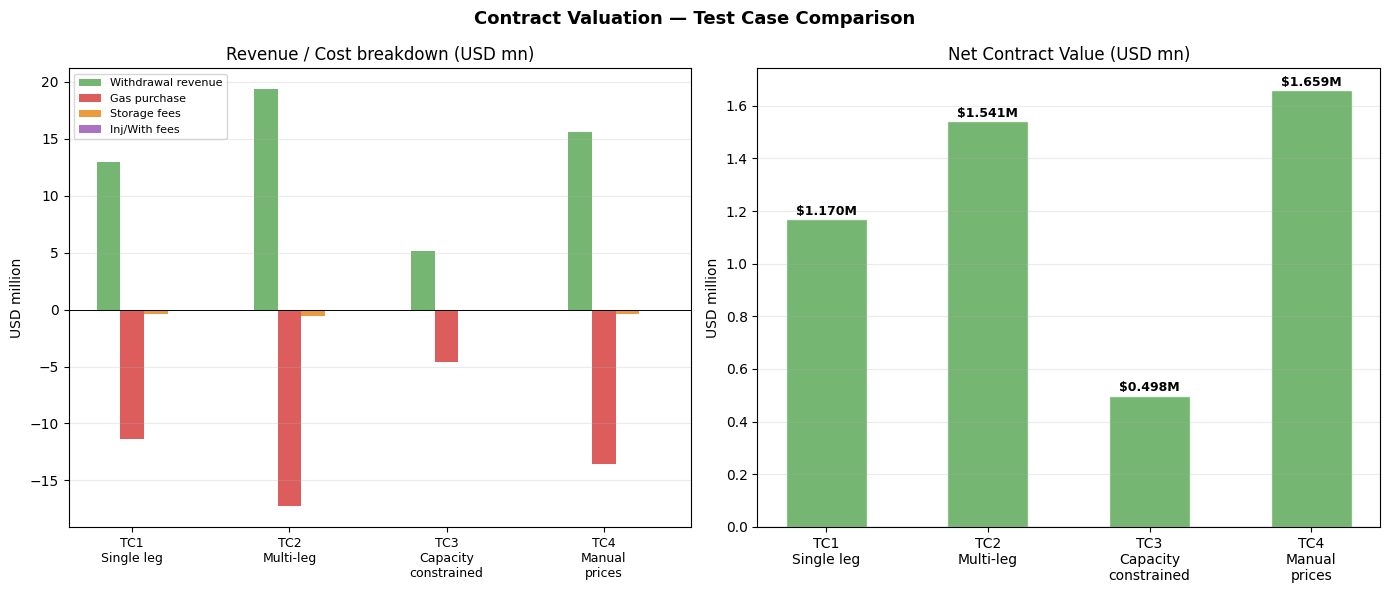

In [21]:
cases   = ["TC1\nSingle leg", "TC2\nMulti-leg", "TC3\nCapacity\nconstrained", "TC4\nManual\nprices"]
results = [r1, r2, r3, r4]

labels  = ["Withdrawal revenue", "Gas purchase", "Storage fees", "Inj/With fees", "Net value"]
colors  = ["#5daa59", "#d84040", "#e8891a", "#9b59b6", "#3266ad"]

data = {
    "Withdrawal revenue": [r["withdrawal_revenue"] / 1e6 for r in results],
    "Gas purchase":       [-r["injection_spend"]   / 1e6 for r in results],
    "Storage fees":       [-r["storage_fee"]        / 1e6 for r in results],
    "Inj/With fees":      [-(r["injection_fee"] + r["withdrawal_fee"]) / 1e6 for r in results],
    "Net value":          [r["value"]               / 1e6 for r in results],
}

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle("Contract Valuation — Test Case Comparison", fontsize=13, fontweight="bold")

# Waterfall-style grouped bar
ax = axes[0]
x   = np.arange(len(cases))
w   = 0.15
for i, (lbl, col) in enumerate(zip(labels[:-1], colors[:-1])):
    ax.bar(x + i * w, data[lbl], width=w, label=lbl, color=col, alpha=0.85)
ax.set_xticks(x + w)
ax.set_xticklabels(cases, fontsize=9)
ax.set_ylabel("USD million")
ax.set_title("Revenue / Cost breakdown (USD mn)")
ax.legend(fontsize=8)
ax.axhline(0, color="black", linewidth=0.7)
ax.grid(True, alpha=0.25, axis="y")

# Net value bar
ax2 = axes[1]
net_vals = data["Net value"]
bar_colors = ["#5daa59" if v >= 0 else "#d84040" for v in net_vals]
bars = ax2.bar(cases, net_vals, color=bar_colors, alpha=0.85, edgecolor="white", width=0.5)
for bar, val in zip(bars, net_vals):
    ax2.text(bar.get_x() + bar.get_width() / 2,
             val + (0.005 if val >= 0 else -0.015),
             f"${val:.3f}M", ha="center", va="bottom", fontsize=9, fontweight="bold")
ax2.axhline(0, color="black", linewidth=0.8)
ax2.set_title("Net Contract Value (USD mn)")
ax2.set_ylabel("USD million")
ax2.grid(True, alpha=0.25, axis="y")
plt.tight_layout()
